## Установка библиотек и подключение google диска

In [ ]:
!pip install transformers

In [ ]:
!pip install iterative-stratification

In [ ]:
!pip install catboost

In [4]:
import kagglehub
from google.colab import drive
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re
import catboost as cb
from sklearn.preprocessing import MultiLabelBinarizer
from transformers import AutoTokenizer
from iterstrat.ml_stratifiers import MultilabelStratifiedKFold
from sklearn.metrics import f1_score , precision_recall_curve, auc, confusion_matrix, precision_score, recall_score
import torch
import torch.nn as nn
from torch.utils.data import Dataset,DataLoader
import torch.nn.functional as F
from transformers import AutoTokenizer,AutoModel, get_linear_schedule_with_warmup
from torch.optim import AdamW
import os
from tqdm.auto import tqdm


In [ ]:
drive.mount('/content/drive')

## Подготовка датафрейма (**toxic russian comments**)

In [ ]:
path = kagglehub.dataset_download("alexandersemiletov/toxic-russian-comments")
parsed_rows = []

with open(path + '/dataset.txt', 'r',encoding = 'utf-8') as t:
  raw_lines = t.readlines()
  pattern1 = r'[A-Z]+'
  pattern2 = r'^((__label__)[A-Z]*(,)?)*'

  for line in raw_lines:
    label = re.findall(pattern1,line)
    text = re.sub(pattern2,'',line).strip()
    parsed_rows.append([label,text])


In [7]:
df1 = pd.DataFrame(data = parsed_rows, columns = ['category', 'text'])

mlb = MultiLabelBinarizer()
array = mlb.fit_transform(df1['category'])

df0 = pd.DataFrame(data = array, columns = ['INSULT','NORMAL','OBSCENITY','THREAT'])

final_df = pd.concat([df1,df0], axis = 1)
final_df.head(15)

,category,text,INSULT,NORMAL,OBSCENITY,THREAT
0,[INSULT],скотина! что сказать,1,0,0,0
1,[NORMAL],я сегодня проезжала по рабочей и между домами ...,0,1,0,0
2,[NORMAL],очередной лохотрон. зачем придумывать очередно...,0,1,0,0
3,[NORMAL],"ретро дежавю ... сложно понять чужое сердце , ...",0,1,0,0
4,[NORMAL],а когда мы статус агрогородка получили?,0,1,0,0
5,[NORMAL],2 августа поздно вечером нашли вот такую потер...,0,1,0,0
6,[NORMAL],вчера надыбала новые стикеры #u2a94ec7fabs#,0,1,0,0
7,"[INSULT, THREAT]",заколоть этого плешивого урода что бы крякнул ...,1,0,0,1
8,[NORMAL],а еще на стоянке никто не проверяет безопаснос...,0,1,0,0
9,[NORMAL],"красота..!! если есть, что показать??!! почему...",0,1,0,0


## **EDA**

In [8]:
%config InlineBackend.figure_format = 'svg'
sns.set_theme('notebook')

In [9]:
sum_NORMAL = final_df['NORMAL'].sum()
sum_INSULT = final_df['INSULT'].sum()
sum_THREAT = final_df['THREAT'].sum()
sum_OBSCENITY = final_df['OBSCENITY'].sum()
category_df = pd.DataFrame({'category' : ['Normal','Insult','Threat','Obscenity'], 'popularity' : [sum_NORMAL,sum_INSULT,sum_THREAT,sum_OBSCENITY] })
category_df['popularity_pct'] = (category_df['popularity'] / len(final_df) ) * 100


Text(0.5, 1.0, 'Процентное соотношение комментариев каждой категории')

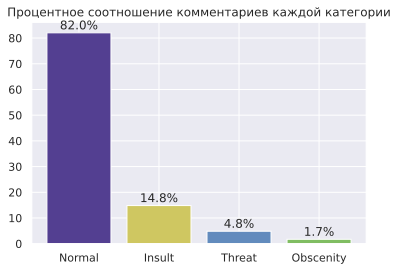

In [10]:
plt.figure(figsize = (6,4))
bars = plt.bar(
    category_df['category'],
    category_df['popularity_pct'],
    color = ['#533f91', '#cfc761','#628bbd','#80bd62']
)
plt.bar_label(bars, fmt='%.1f%%', padding=1)
plt.title('Процентное соотношение комментариев каждой категории')

**Выводы по столбчатой диаграмме :**
- Нормальный комментариев 82%
- Оскорбления встречаются в 14.8% комментариев.
- Угрозы содержатся в 4.8% комментариев.
- Нецензурная лексика в 1.7% комментариев.


--------
82 + 1.7 + 4.8 + 14.8 = 103.3 (некоторые комменатрии относятся к нескольким категориям одновременно).

### **Исследование длин комментариев для оптимизации Max Length**

In [11]:
final_df['text'].str.split().str.len().describe()

,text
count,248290.000000
mean,12.500230
std,15.419661
min,1.000000
25%,4.000000
50%,8.000000
75%,14.000000
max,267.000000


In [ ]:
text = 'ты тупой !не пиши сюда больше и изолируйся от общества!!!'

tokenizer = AutoTokenizer.from_pretrained(
    'DeepPavlov/rubert-base-cased-conversational'
)
t = tokenizer.encode(text)
print(f'кол-во слов в фразе : {len(text.split())}')
print(f'кол-во токенов в фразе : {len(t)}')

In [ ]:
tokenizer.tokenize(text)

75% всех комментариев датасета укладываются всего в 14 слов. При переводе 14 слов в токены понадобится примерно 25 токенов. Возьмем 128 за максимальное количество токенов на один комментарий (запас для более длинных текстов, короткие тексты будут дозаполнены PAD-токенами).

In [14]:
max_length = 128

## Разбиение данных на фолды для кросс-валидации

Для построения схемы кросс-валидации применю алгоритм **Multilabel StratifiedKFold**, т.к одному комментарию может соответствовать несколько меток сразу (мультилейбл, возможные метки :  normal, insult, threat,obscenity) + присутствует сильный дисбаланс редких меток (threat - 4.8%, obscenity - 1.7 %)

StratifiedKFold  справляется с дисбалансом классов, но работает только с одной колонкой таргета. MultilabelStratifiedKFold решает эту проблему,сохраняя пропорции редких классов сразу во всех целевых переменных каждого фолда.


In [15]:
final_df.columns

Index(['category', 'text', 'INSULT', 'NORMAL', 'OBSCENITY', 'THREAT'], dtype='object')

In [16]:
mskf = MultilabelStratifiedKFold(n_splits = 5, shuffle = True, random_state = 42)
final_df['fold_idx'] = -1

X = final_df['text']
y = final_df[['INSULT', 'NORMAL', 'OBSCENITY', 'THREAT']]

for fold_idxX, (train_idx, val_idx) in enumerate(mskf.split(X,y)): #train_idx - индксы строк обучающей выборки; val_idx - индексы строк валидационной выборки
  final_df.loc[val_idx, 'fold_idx'] = fold_idxX

final_df['fold_idx'].value_counts()

,count
fold_idx,
3,49715
4,49659
2,49646
1,49645
0,49625


## Валидация градиентного бустинга  и сбор OOF-предсказаний

Чтобы оценить качество CatBoost и подготовить данные для второго уровня
 (RuBERT), я использовала технику **OOF предсказаний**.

Внутри цикла кросс- валидации модель обучалась на 4 фолдах, а предсказания вероятностей  делала для оставшегося 5-го фолда, который она не видела в процессе обучения.Эти  предсказания я поэтапно добавляла в массив OOF по индексам val_idx



In [17]:
OOF = np.zeros((len(final_df), 4))

In [18]:
true_pred = np.zeros((len(final_df),4))

In [19]:
for fold_idx in range(5):
  X_train = final_df[final_df['fold_idx'] != fold_idx][['text']]
  y_train = final_df[final_df['fold_idx'] != fold_idx][['INSULT', 'NORMAL', 'OBSCENITY', 'THREAT']]
  X_val = final_df[final_df['fold_idx'] == fold_idx][['text']]
  y_val = final_df[final_df['fold_idx'] == fold_idx][['INSULT', 'NORMAL', 'OBSCENITY', 'THREAT']]
  print(f"Фолд {fold_idx}: Кол-во строк в тренировочной выборке = {X_train.shape}, Кол-во строк в валидационной выборке = {X_val.shape}")

  train_pool = cb.Pool(
      data = X_train,
      label = y_train,
      text_features = ['text']
  )
  val_pool = cb.Pool(
      data = X_val,
      label = y_val,
      text_features = ['text']
  )

  model_cb = cb.CatBoostClassifier(iterations = 2000,
                                loss_function = 'MultiLogloss',
                                learning_rate = 0.05,
                                task_type = 'GPU',
                                random_seed = 42
                                )
  model_cb.fit(
      X = train_pool,
      eval_set = val_pool,
      verbose = False
  )
  pred = model_cb.predict_proba(val_pool)
  OOF[y_val.index] = pred

  true_pred[y_val.index] = y_val

Фолд 0: Кол-во строк в тренировочной выборке = (198665, 1), Кол-во строк в валидационной выборке = (49625, 1)
Фолд 1: Кол-во строк в тренировочной выборке = (198645, 1), Кол-во строк в валидационной выборке = (49645, 1)
Фолд 2: Кол-во строк в тренировочной выборке = (198644, 1), Кол-во строк в валидационной выборке = (49646, 1)
Фолд 3: Кол-во строк в тренировочной выборке = (198575, 1), Кол-во строк в валидационной выборке = (49715, 1)
Фолд 4: Кол-во строк в тренировочной выборке = (198631, 1), Кол-во строк в валидационной выборке = (49659, 1)


In [20]:
np.set_printoptions(suppress = True, precision = 6)
OOF

array([[0.842745, 0.154648, 0.013389, 0.024922],
       [0.004319, 0.993804, 0.000746, 0.000497],
       [0.031457, 0.964657, 0.003187, 0.000827],
       ...,
       [0.011301, 0.987468, 0.002085, 0.000404],
       [0.005319, 0.993364, 0.000946, 0.000541],
       [0.011564, 0.98823 , 0.000184, 0.000283]])

## Из-за сильного дисбаланса классов буду применять **F1 score** и **Precision-Recall Curve**.

Cначала посмотрим на качество модели при стандартном пороге отсечения (0.5)

In [21]:
OOF_bool = (OOF >= 0.5).astype(int)
f1 = f1_score(true_pred, OOF_bool, average = 'macro')
print(f'F1-score: {f1:.4f}')

F1-score: 0.7949


In [22]:
auc_metrics = []
for i in range(4):
  precision, recall, threshold = precision_recall_curve(true_pred[0:,i], OOF[0:,i])
  pr_auc = auc(recall,precision)
  auc_metrics.append(pr_auc)

average_auc = np.mean(auc_metrics)
print(f'Средняя площадь под PR-кривой : {average_auc:.4f}')

Средняя площадь под PR-кривой : 0.8491


## Оптимизация порогов для F1-score каждого класса

In [23]:
best_thresholds = []
f1_score_ = []

for i in range(4):
  f1_tr_storage = []

  for tr in np.arange(0.05,0.9,0.05):
    OOF_bool_ch = (OOF[0:,i] >= tr).astype(int)
    f1_sc = f1_score(true_pred[0:,i],OOF_bool_ch)
    f1_tr_storage.append([f1_sc,tr])

  best_tr = max(f1_tr_storage, key = lambda x : x[0])[1]
  best_thresholds.append(best_tr)
  best_f1 =  max(f1_tr_storage, key = lambda x : x[0])[0]
  f1_score_.append(best_f1)

print(best_thresholds)
print(f1_score_)

best_threshold_for_category = {'INSULT': 0.4, 'NORMAL' : 0.5, 'OBSCENITY' : 0.3, 'THREAT' : 0.4}

print(best_threshold_for_category)

[np.float64(0.4), np.float64(0.5), np.float64(0.3), np.float64(0.4)]
[0.7912448144817382, 0.967238922734582, 0.6729346872257741, 0.7820939376917426]
{'INSULT': 0.4, 'NORMAL': 0.5, 'OBSCENITY': 0.3, 'THREAT': 0.4}


In [24]:
new_f1_score = np.mean(f1_score_)
print(f'Средний F1-score: {new_f1_score:.4f}')

Средний F1-score: 0.8034


### Результаты подбора наилучшего порога для каждой категории


**Оптимальные пороги :**
* `INSULT`: **0.40** (F1: 0.7912)
* `NORMAL`: **0.50** (F1: 0.9672)
* `OBSCENITY`: **0.30** (F1: 0.6729)
* `THREAT`: **0.40** (F1: 0.7821)

**Итог:**
Метрика **Macro F1-Score поднялась с 0.7949 до 0.8033** благодаря threshold tuning


### Выделение «серой зоны» для обучения RuBERT (L2)

Я добавила отступ от каждого оптимального порога(best_thresholds) на ±0.20. Вероятность класса попадает в этот интервал, когда модель колеблется в решении.

**Правило отбора для обучения L2:**
Если CatBoost засомневался **хотя бы в одном** из 4 классов, этот комментарий  отправляется в датасет для NLP. На этапе обучения собираю для трансформера  спектр скрытых паттернов (например, скрытая угроза, замаскированная очевидным матом), чтобы модель L2 стала экспертом в спорных кейсах.


In [25]:
tr_ins = 0.4
tr_norm = 0.5
tr_obsc = 0.3
tr_thr = 0.4

mask_ins = (OOF[0:,0] >= (tr_ins - 0.2)) & (OOF[0:,0] <= (tr_ins + 0.2))
mask_norm = (OOF[0:,1] >= (tr_norm - 0.2)) & (OOF[0:,1] <= (tr_norm + 0.2))
mask_obsc = (OOF[0:,2] >= (tr_obsc - 0.2)) & (OOF[0:,2] <= (tr_obsc + 0.2))
mask_thr = (OOF[0:,3] >= (tr_thr - 0.2)) & (OOF[0:,3] <= (tr_thr + 0.2))

grey_zone_mask = mask_ins | mask_norm | mask_obsc | mask_thr

grey_zone_df = final_df[grey_zone_mask]
grey_zone_df

,category,text,INSULT,NORMAL,OBSCENITY,THREAT,fold_idx
12,[NORMAL],ои уже и етому учат,0,1,0,0,3
13,[NORMAL],"эти скаты ,на героев пионеров, анекдотов навыд...",0,1,0,0,2
28,[NORMAL],пиши сразу путину раз такая смелая,0,1,0,0,1
33,[NORMAL],секс мосаж чтоли?,0,1,0,0,3
34,[INSULT],"мляяя..фомин..ты издесь умничаешь,чайка помойн...",1,0,0,0,3
...,...,...,...,...,...,...,...
248215,[NORMAL],"чем, должен привлечь так, этот 5g, что бы нажа...",0,1,0,0,1
248251,[NORMAL],когда бог хочет наказать он забирает ум а безм...,0,1,0,0,2
248274,[INSULT],сом вец ук сиар я поднял страну колен с асии и...,1,0,0,0,4
248279,[NORMAL],ни стыда ни совести иди на огород поработай,0,1,0,0,0


In [26]:
grey_zone_df.shape[0] / final_df.shape[0] * 100

9.53320713681582

### Выделение «серой зоны» и оценка экономии ресурсов GPU


**Результаты:**
* Размер исходного датасета: `248290` комментариев.
* Размер датасета для обучения трансформера : `23670` комментариев.
* Доля усложненных кейсов: **9.53%**

**Вывод:**
Каскадная архитектура (L1 CatBoost + L2 RuBERT) позволяет выполнить **90.47%** модерации на быстрых CPU-вычислениях без потери качества( градиентный бустинг нормально обучается на ЦП) . Тяжелый NLP-трансформер будет обрабатывать менее 10% самых неоднозначных текстов, что сокращает потенциальные затраты на инфраструктуру GPU в 10 раз.


## **Дообучение NLP-трансформера**

## Основные параметры модели

In [27]:
MODEL_NAME = 'DeepPavlov/rubert-base-cased-conversational'
BATCH_SIZE = 32
MAX_LENGTH = 128 #вообще я это уже указывала выше и объясняла свой выбор
NUM_EPOHS = 5
RANDOM_SEED = 42

## Класс TextDataset, который представит данные уже в токенизированной форме

In [28]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

In [29]:
class TextDataset(Dataset):
  def __init__(self,df,tokenizer, max_length = 128):
    self.texts = df.text.tolist()
    self.labels = df[['INSULT',	'NORMAL',	'OBSCENITY',	'THREAT']].values.tolist()
    self.tokenizer = tokenizer
    self.max_length = max_length

  def __len__(self):
    return len(self.texts)

  def __getitem__(self,idx):
    text = str(self.texts[idx])
    label = self.labels[idx]

    encoding = self.tokenizer(
        text,
        truncation = True,
        padding = 'max_length',
        max_length = self.max_length,
        return_tensors = 'pt'
    )

    return{
        'input_ids' : encoding['input_ids'].flatten(),
        'attention_mask' : encoding['attention_mask'].flatten(),
        'label' : torch.tensor(label, dtype = torch.float)
    }

### Валидация для RuBERT (L2)

Чтобы  оценить качество нейросети на этапе глубокого обучения и избежать переобучения , разделяю «серую зону» на Train и Validation на основе ранее созданных фолдов:

* **Тренировочный датасет :** Включает данные из фолдов 1, 2, 3, 4 . На этих сложных примерах NLP будет подстраивать свои веса.
* **Валидационный датасет :** Включает данные из фолда 0. Для замера метрик на валидации.

Поскольку исходное разделение на фолды было сделано через MultilabelStratifiedKFold, пропорции всех редких классов в фолде 0 соответствуют остальному датасету

In [30]:
train_dataset = TextDataset(
    grey_zone_df[grey_zone_df['fold_idx'] != 0],
    tokenizer
)
val_dataset = TextDataset(
    grey_zone_df[grey_zone_df['fold_idx'] == 0],
    tokenizer
)

In [52]:
train_dataset[2]

{'input_ids': tensor([  101, 25213,  1840, 52712,   893,  2299, 91406,   102,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,   

In [32]:
train_loader = DataLoader(
    train_dataset,
    batch_size = BATCH_SIZE,
    shuffle = True
)
val_loader = DataLoader(
    val_dataset,
    batch_size = BATCH_SIZE,
    shuffle = True
)

In [33]:
batch = next(iter(train_loader))

In [ ]:
batch

In [35]:
print(f'Число спусков на одну эпоху : {len(train_loader)}')

Число спусков на одну эпоху : 592


#### Число спусков на 1 эпоху обучения - 592.
 Буду дообучать RuBert за 3 эпохи по двум причинам :
 - RuBert была обучена на dirty, Pikabu, постах и комментариях в социальных сетях .Т.е. этот трансформер уже хорошо знаком с тем, как комментаторы могут завуалировать мат, написать скрытую угрозу и т.п.
 - Чтобы избежать переобучение.

In [36]:
class BERT_MODEL(nn.Module):
  def __init__(self,model_name = 'DeepPavlov/rubert-base-cased-conversational'):
    super().__init__()
    self.bert = AutoModel.from_pretrained(model_name)
    self.classifier = nn.Linear(self.bert.config.hidden_size,4)

  def forward(self, input_ids, attention_mask):
    outputs = self.bert(input_ids = input_ids, attention_mask = attention_mask)
    pooled_output = outputs.last_hidden_state[:,0]
    logits = self.classifier(pooled_output)
    return logits

### Функция для вычисления метрик на этапе валидации

In [37]:
def metrics(predictions, labels, threshold = 0.5):

  binary_predictions = (predictions >= threshold).astype(int)
  f1_score_v = f1_score(labels, binary_predictions,average='macro')
  precision_Score = precision_score(labels,binary_predictions, average='macro')
  recall_Score = recall_score(labels, binary_predictions, average='macro')

  return{
      'F1' : f1_score_v,
      'precision' : precision_Score,
      'recall' : recall_Score
  }

###Реализация MultiLabel Focal Loss

Для борьбы с экстремальным дисбалансом я написала функцию потерь **Focal Loss** для мультилейбла.
За счет  множителя $(1 - p_t)^\gamma$ алгоритм уменьшает штрафы за легкие предсказания и искусственно увеличивает на сложных кейсах. Это заставит BERT сфокусировать внимание на скрытых угрозах.


In [38]:
class MultiLabelFocalLoss(nn.Module):
  def __init__(self,alpha : float = 0.25 ,gamma : float = 2.0, reduction : str = 'mean'):
    super().__init__()
    self.alpha = alpha
    self.gamma = gamma
    self.reduction = reduction

  def forward(self, inputs : torch.Tensor, targets : torch.Tensor) -> torch.Tensor :
    assert inputs.shape == targets.shape, f'Ошибка!!! размер логитов {inputs.shape} не совпадает с метками {targets.shape}'
    targets_float = targets.float()

    bce = F.binary_cross_entropy_with_logits(inputs,targets_float , reduction = 'none')
    pred = torch.sigmoid(inputs)

    pt = targets_float * pred + (1 - targets_float) * (1 - pred)

    focal_weight = (1 - pt) ** self.gamma

    alpha_weight = targets_float * self.alpha + (1 - targets_float) * (1 - self.alpha)

    loss = alpha_weight * focal_weight * bce

    if self.reduction == 'mean' :
      return loss.mean()
    else :
      return loss



In [ ]:
model = BERT_MODEL()

### Цикл обучения на T4 GPU :
* Обучение ограничено **3 эпохами**, чтобы предотвратить переобучение тяжелой модели на небольшом датасете серой зоны.
* В качестве оптимизатора  **`AdamW`** с линейным прогревом скорости обучения (`get_linear_schedule_with_warmup`).
* Классификация по **`CLS`-токену**, который впитывает смысл всего комментария на протяжении 12 слоев внимания трансформера.
* Если текущий Macro F1-score на валидации больше наибольшего из предыдущих значений,то веса модели автоматически сохраняются в файл `best_model.pth`.


In [40]:
def train_model(model, train_loader, val_loader, device, num_epochs = 3):
  model.to(device)

  total_steps = len(train_loader) * num_epochs
  warmup_steps = int(0.05 * total_steps)

  loss_func = MultiLabelFocalLoss()

  optimizer = AdamW(
      model.parameters(),
      lr = 3e-5,
      weight_decay = 0.01
  )
  scheduler = get_linear_schedule_with_warmup(
      optimizer,
      num_warmup_steps = warmup_steps,
      num_training_steps = total_steps
  )

  train_losses = []
  val_losses = []

  best_val_f1 = 0

  for epoch in range(num_epochs):
    print(f'Это {epoch + 1} из {num_epochs}')

    model.train()
    total_train_loss = 0

    for batch in tqdm(train_loader, desc = f'Training', leave = False):
      input_ids = batch['input_ids'].to(device)
      attention_mask = batch['attention_mask'].to(device)
      labels = batch['label'].to(device)

      optimizer.zero_grad()
      outputs = model(input_ids, attention_mask)

      loss = loss_func(outputs,labels)

      loss.backward()
      torch.nn.utils.clip_grad_norm_(model.parameters(),1.0)
      optimizer.step()
      scheduler.step()

      total_train_loss += loss.item()

    train_losses.append(total_train_loss / len(train_loader))

#валидация
    model.eval()
    total_val_loss = 0
    val_predictions = []
    val_labels = []

    with torch.no_grad():
        for batch in tqdm(val_loader, desc = f'Validation', leave = False):
          input_ids = batch['input_ids'].to(device)
          attention_mask = batch['attention_mask'].to(device)
          labels = batch['label'].to(device)

          outputs = model(input_ids,attention_mask)

          loss = loss_func(outputs,labels)
          total_val_loss += loss.item()

          predictions = torch.sigmoid(outputs).cpu().numpy()
          val_predictions.extend(predictions)
          val_labels.extend(labels.cpu().numpy())

    val_losses.append(total_val_loss/len(val_loader))

    val_metrics = metrics(np.array(val_predictions),np.array(val_labels))
    current_f1 = val_metrics['F1']
    current_recall = val_metrics['recall']
    current_precision = val_metrics['precision']

    print(f' Train Loss : {train_losses[-1]:.4f}, Validation Loss : {val_losses[-1]:.4f}, F1 - score : {current_f1:.4f}, Precision : {current_precision:.4f}, Recall : {current_recall:.4f}')

    if current_f1 > best_val_f1:
      best_val_f1 = current_f1
      torch.save(model.state_dict(), 'best_model.pth')
      print('Веса модели обновлены, тк текущий f1 наибольший')

  print(f'Обучение окончено, самый большой F1-score на валидации : {best_val_f1 :.4f}')

  return model,train_losses,val_losses


### Запуск обучения

In [ ]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

final_model, training_loss, validation_loss = train_model(
    model = model,
    train_loader = train_loader,
    val_loader = val_loader,
    device = device,
    num_epochs = 3
)

----------

## Финальный каскад `CatBoost` и `RuBERT`

**Как устроен каскад :**

1.  Используются веса с 3 эпохи дообучения NLP (f1-score с наибольшими показателями был на третьей эпохе)  из файла `best_model.pth`. Модель переведена на ЦП и включен режим оценки (.eval()) .
2.  Используются оптимальные пороги для каждого класса, которые были найдены ранее через перебор.
3. **Логика функции `final_decision`:**
   * Текст сначала отправляется в градиентный бустинг. Если там явный мат или угроза выше порогов - сразу возвращается `БАН` и не тратится время и GPU.
   * Если бустинг уверен, что текст нормальный (`> 0.5`), а вероятность угрозы, мата, оскорбления в предсказании CatBoostClassifier yf 20 % ниже от установленного порога, то текст чистый - возвращается `ПРОПУСТИТЬ`.
   * Если текст не подошёл под первые два правила - значит, `CatBoost` неуверен. Текст передается в БЕРТ модель, которая вникает в сложный контекст и выносит окончательный вердикт по тем же порогам.


In [ ]:
final_bert_model = BERT_MODEL()

final_bert_model.load_state_dict(torch.load('best_model.pth', map_location=torch.device('cuda')))
final_bert_model.to('cuda')
final_bert_model.eval()



In [43]:
tr_ins = 0.4
tr_norm = 0.5
tr_obsc = 0.3
tr_thr = 0.4
#раннее найденные идеальные пороги

In [50]:
def final_decision(text):
  txt = str(text)
  prob_insult , prob_normal, prob_obscenity, prob_threat = model_cb.predict_proba([txt],thread_count=-1) #catboost на цп

  if prob_insult >= tr_ins or prob_obscenity >= tr_obsc or prob_threat >= tr_thr:
    return 'БАН'
  elif prob_normal > tr_norm and prob_insult < (tr_ins - 0.2) and prob_obscenity < (tr_obsc - 0.2) and prob_threat < (tr_thr - 0.2):
    return 'Нормальный комментарий'

  else :
    inp = tokenizer(text, max_length=128, padding='max_length', truncation=True, return_tensors='pt')
    input_ids = inp['input_ids'].to('cuda')
    attention_mask = inp['attention_mask'].to('cuda')

    with torch.no_grad():
      logits = final_bert_model(input_ids, attention_mask)
      bert_probs = torch.sigmoid(logits).cpu().numpy()[0]

    prob_insult1 , prob_normal1, prob_obscenity1, prob_threat1 = bert_probs

    if prob_insult1 >= tr_ins or prob_obscenity1 >= tr_obsc or prob_threat1 >= tr_thr:
      return 'БАН'
    else:
      return 'Нормальный комментарий'







In [46]:
final_df['verdict'] = final_df['text'].apply(lambda x : final_decision(x) )

In [47]:
final_df['verdict'].value_counts()


,count
verdict,
Нормальный комментарий,205976
БАН,42314


In [48]:
final_df.shape

(248290, 8)

Text(0.5, 1.0, 'Соотношение допустимых комментариев и тех, что стоит забанить')

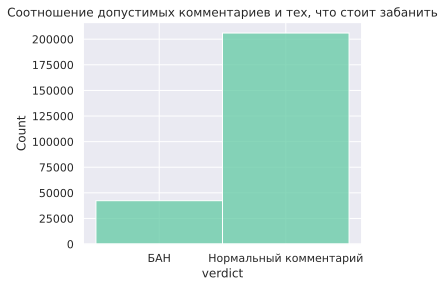

In [49]:
plt.figure(figsize = (5,4))
sns.histplot(
    final_df['verdict'],
    color = '#61c9a3'
)
plt.title('Соотношение допустимых комментариев и тех, что стоит забанить')

## Итоги проекта:Финальные результаты работы каскада

Каскадная система модерации текстового контента полностью протестирована на всём объёме данных (248 290 комментариев).

**Результаты работы каскада:**
* Одобрено к публикации (`Нормальный комментарий`): **205 951**
* Заблокировано (`БАН`): **42 339** (17.05% от общего потока)

**Главный вывод:**
Проект успешно завершён. Архитектура двухэтапного каскада полностью оправдала себя на практике. Модель первого уровня (`CatBoost`) мгновенно отсекла более 90% очевидных данных, а тяжёлый NLP-трансформер `RuBERT`, дообученный с помощью `MultiLabelFocalLoss` разобрал оставшуюся «серую зону» сомнений, подняв итоговое качество системы до **Macro F1 = 0.8619**.Получен мощный инструмент модерации, который экономит ресурсы серверов в 10 раз и надёжно защищает платформу от токсичности, мата и скрытых угроз.
